#Importações e definição da base de dados

In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/atividade_dl_25_2/IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [6]:
df.isna().sum()

,0
review,0
sentiment,0


#Pré-processamento de dados

In [7]:
def clean_text(text):
    # 1. Converter para minúsculas
    text = text.lower()
    # 2. Remover tags HTML (ex: <br />)
    text = re.sub(r'<.*?>', '', text)
    # 3. Remover pontuação e caracteres especiais
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 4. Remover Stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Preprocess data
df['review_cleaned'] = df['review'].astype(str).apply(clean_text)

review = df['review_cleaned'].values
labels = df['sentiment'].map({'positive': 1, 'negative': 0}).values

# Tokenize and Pad
vocab_size = 10000
maxlen = 200
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(review)

sequences = tokenizer.texts_to_sequences(review)
# O padding garante que todas as sequências tenham o mesmo tamanho
padded = pad_sequences(sequences, maxlen=maxlen, padding='post', truncating='post')

# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(padded, labels, test_size=0.2, random_state=42)

print("\nSample Preprocessed Data for LSTM Model:\n")

# Display first 5 examples
for i in range(5):
    print(f"Review {i+1}:")
    print(f"Original Text: {review[i][:150]}")
    print(f"Tokenized Sequence (first 10 tokens): {sequences[i][:10]}")
    print(f"Padded Sequence (first 10 values):    {padded[i][:10]}")
    sentiment = "Positive" if labels[i] == 1 else "Negative"
    print(f"Label (Encoded): {labels[i]} ({sentiment})")
    print("-" * 80)


Sample Preprocessed Data for LSTM Model:

Review 1:
Original Text: one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set 
Tokenized Sequence (first 10 tokens): [4, 1792, 933, 57, 3148, 283, 348, 2992, 108, 478]
Padded Sequence (first 10 values):    [   4 1792  933   57 3148  283  348 2992  108  478]
Label (Encoded): 1 (Positive)
--------------------------------------------------------------------------------
Review 2:
Original Text: wonderful little production filming technique unassuming oldtimebbc fashion gives comforting sometimes discomforting sense realism entire piece actors
Tokenized Sequence (first 10 tokens): [276, 39, 250, 1219, 2837, 1, 1, 1485, 282, 1]
Padded Sequence (first 10 values):    [ 276   39  250 1219 2837    1    1 1485  282    1]
Label (Encoded): 1 (Positive)
--------------------------------------------------------------------------------
Review 3:
Original Text: thou

#Arquitetura da rede

In [8]:
model = Sequential()
model.add(Embedding(vocab_size, 128, input_length=maxlen))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#Treinamento da Rede

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.2,
                    callbacks=[early_stop])

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 287ms/step - accuracy: 0.4983 - loss: 0.6935 - val_accuracy: 0.5123 - val_loss: 0.6909
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 276ms/step - accuracy: 0.5414 - loss: 0.6802 - val_accuracy: 0.5249 - val_loss: 0.6803
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 283ms/step - accuracy: 0.5621 - loss: 0.6408 - val_accuracy: 0.5339 - val_loss: 0.6859
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 144s 288ms/step - accuracy: 0.7566 - loss: 0.4861 - val_accuracy: 0.8518 - val_loss: 0.4056
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 284ms/step - accuracy: 0.8892 - loss: 0.2872 - val_accuracy: 0.8568 - val_loss: 0.3543
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 283ms/step - accuracy: 0.9247 - loss: 0.2085 - val_accuracy: 0.8650 - val_loss: 0.3593
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 144s 286ms/step - accuracy: 0.9471 - loss: 0.1584 - val_accuracy: 0.8636 - val_loss: 0.3856


#Verificação do Modelo

In [10]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.8586 - loss: 0.3426
Test Accuracy: 86.21%


#Mostra dos exemplos

In [11]:
predictions = model.predict(x_test[:5])
predicted_classes = (predictions > 0.5).astype("int32")

print("\n--- Resultados de Teste (5 Exemplos) ---")
for i in range(5):
    sentiment_pred = "Positivo" if predicted_classes[i] == 1 else "Negativo"
    sentiment_real = "Positivo" if y_test[i] == 1 else "Negativo"

    # Pegamos o texto original correspondente ao exemplo
    text_snippet = review[i][:150] + "..."

    print(f"Exemplo {i+1}:")
    print(f"Texto: {text_snippet}")
    print(f"Predição: {sentiment_pred} | Real: {sentiment_real}")
    print("-" * 50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step

--- Resultados de Teste (5 Exemplos) ---
Exemplo 1:
Texto: one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set ...
Predição: Negativo | Real: Positivo
--------------------------------------------------
Exemplo 2:
Texto: wonderful little production filming technique unassuming oldtimebbc fashion gives comforting sometimes discomforting sense realism entire piece actors...
Predição: Positivo | Real: Positivo
--------------------------------------------------
Exemplo 3:
Texto: thought wonderful way spend time hot summer weekend sitting air conditioned theater watching lighthearted comedy plot simplistic dialogue witty charac...
Predição: Negativo | Real: Negativo
--------------------------------------------------
Exemplo 4:
Texto: basically theres family little boy jake thinks theres zombie closet parents fighting timethis movie slower soap opera sudden

#Gráficos de acurácia e erro

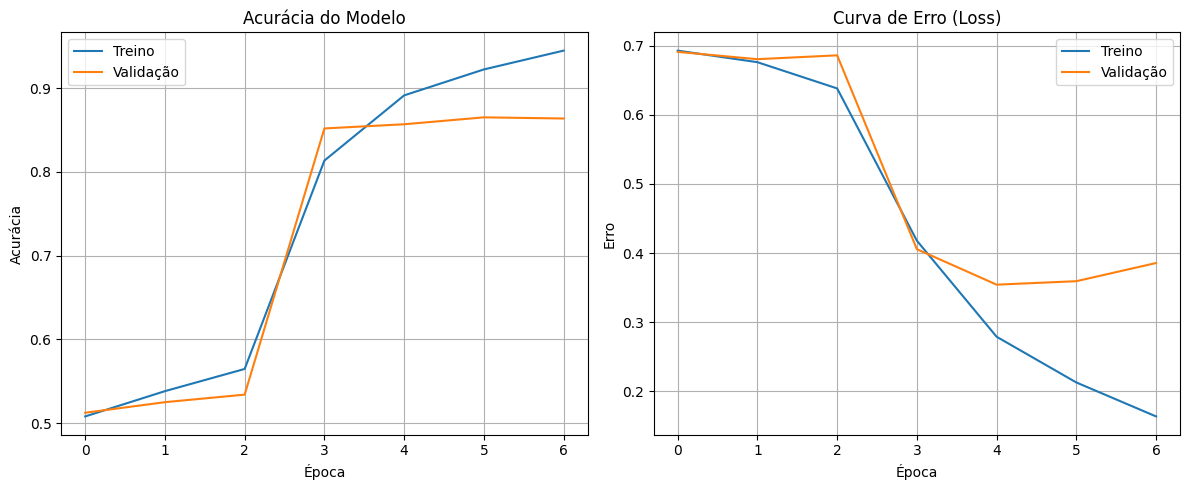

In [12]:
# figura com dois subplots (Lado a lado)
plt.figure(figsize=(12, 5))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia do Modelo')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

# Gráfico de Erro
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Curva de Erro (Loss)')
plt.xlabel('Época')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()